In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_csv(r"C:\Users\Khande\Desktop\project 2\Customer-Churn-Prediction\data\customer_churn_preprocessed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [5]:
rf_model = joblib.load(r"C:\Users\Khande\Desktop\project 2\Customer-Churn-Prediction\models\random_forest_model.pkl")

In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Number of Features:", X.shape[1])

Number of Features: 19


In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
18,TotalCharges,0.186841
17,MonthlyCharges,0.179192
4,tenure,0.154338
14,Contract,0.079631
16,PaymentMethod,0.050095
8,OnlineSecurity,0.049580
11,TechSupport,0.043603
0,gender,0.027892
7,InternetService,0.027789
9,OnlineBackup,0.027075


In [8]:
top10 = feature_importance.head(10)

top10

,Feature,Importance
18,TotalCharges,0.186841
17,MonthlyCharges,0.179192
4,tenure,0.154338
14,Contract,0.079631
16,PaymentMethod,0.050095
8,OnlineSecurity,0.049580
11,TechSupport,0.043603
0,gender,0.027892
7,InternetService,0.027789
9,OnlineBackup,0.027075


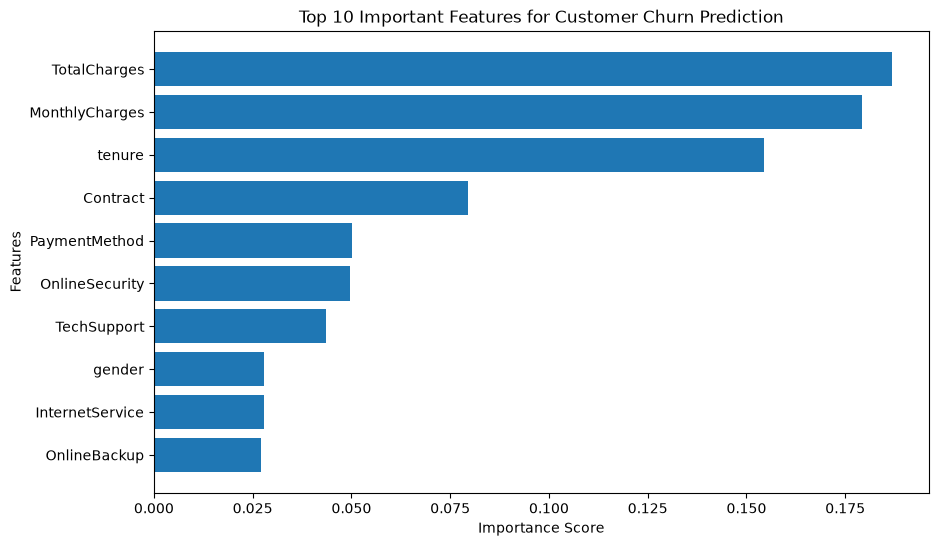

In [9]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features for Customer Churn Prediction")

plt.gca().invert_yaxis()

plt.show()

In [14]:
feature_importance.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [15]:
print("Top 5 Most Important Features\n")

for i in range(5):
    print(
        f"{i+1}. {feature_importance.iloc[i]['Feature']} "
        f"({feature_importance.iloc[i]['Importance']:.4f})"
    )

Top 5 Most Important Features

1. TotalCharges (0.1868)
2. MonthlyCharges (0.1792)
3. tenure (0.1543)
4. Contract (0.0796)
5. PaymentMethod (0.0501)
